## **Homework 01 - Stock Markets Analytics -  Zoomcamp 2026**

## **Imports**

In [412]:
import requests
import pandas as pd
import io
import yfinance as yf
import matplotlib.pyplot as plt

from datetime import datetime

## **Question 01**

- **Problem statement: Which year had the highest number of additions (starting from 2020)?**

- **Additional Problem statement: How many current S&P 500 stocks have been in the index for more than 20 years?**

### **Solution**

In [413]:
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

# Fetch the HTML content with headers
response = requests.get(url, headers=headers)

In [414]:
tables = pd.read_html(io.StringIO(response.text))

for table in tables:
    table_df = pd.DataFrame(table)
    display(table_df)
    

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927


,vteS&P 500 companies,vteS&P 500 companies.1
0,Energy,APA Corporation Baker Hughes Chevron Corporati...
1,Materials,Air Products Albemarle Corporation Amcor Avery...
2,Industrials,3M A. O. Smith Allegion Ametek Automatic Data ...
3,Consumer discretionary,Airbnb Amazon Aptiv AutoZone Best Buy Booking ...
4,Consumer staples,Altria Archer Daniels Midland Brown-Forman Bun...
5,Health Care,Abbott Laboratories AbbVie Agilent Technologie...
6,Financials,Aflac Allstate American Express American Inter...
7,Information technology,Accenture Adobe Inc. Akamai Technologies AMD A...
8,Communication services,Alphabet Inc. AT&T Charter Communications Comc...
9,Real estate,Alexandria Real Estate Equities American Tower...


In [415]:
type(tables[0]["Date added"][0])

str

In [416]:
df_sp500 = pd.DataFrame(tables[0])

df_sp500.columns = df_sp500.columns.str.lower().str.replace(" ", "_")

df_sp500["date_added"] = pd.to_datetime(df_sp500["date_added"])

df_sp500["year_added"] = [int(date.strftime("%Y")) for date in df_sp500["date_added"]]

- **Which year had the highest number of additions (starting from 2020)?**

In [417]:
summary_total_add_by_year = (
    df_sp500
    .loc[df_sp500["year_added"] >= 2020]
    .groupby(["year_added"], as_index=True)
    .agg(
        total_by_year=("year_added", "size"),
    )
    .sort_values(["total_by_year"], ignore_index=False, ascending=False)
)

display(summary_total_add_by_year)

,total_by_year
year_added,
2025,18
2024,16
2022,15
2023,15
2026,13
2021,10
2020,10


> **Answer:** 2025 had the highest number of additions since 2020, with 18 new entrants - the most among complete years (2026 is excluded from the comparison since it is still in progress).

- **Additional: How many current S&P 500 stocks have been in the index for more than 20 years?**

In [418]:
pd.Timestamp.now() - pd.DateOffset(years=20)

Timestamp('2006-09-13 15:37:11.619137')

In [419]:
added_over_20_years = df_sp500["date_added"] < (pd.Timestamp.now() - pd.DateOffset(years=20))

summary_stocks_20_years = (
    df_sp500[added_over_20_years]
    .groupby(["date_added"], as_index=True)
    .agg(
        total_added_by_date=("date_added", "size"),
    )
)

display(summary_stocks_20_years)

,total_added_by_date
date_added,
1957-03-04,52
1964-06-30,1
1965-03-31,2
1969-03-31,1
1969-06-30,1
...,...
2006-01-05,1
2006-02-01,1
2006-04-03,2


In [420]:
summary_stocks_20_years["total_added_by_date"].sum()

np.int64(224)

> **Answer:** 224 companies currently in the S&P 500 were added to the index more than 20 years ago.

## **Question 02**

- **Problem statement: How many indexes (out of 10) have better year-to-date returns than the US (S&P 500) as of August 21, 2026?**

- **Additional Problem statement: How many of these indexes have better returns than the S&P 500 over 3, 5, and 10 year periods? Do you see the same trend?**

### **Solution**

In [421]:
indexes = ["^GSPC", "000001.SS", "^HSI", "^AXJO", "^NSEI", "^GSPTSE", "^GDAXI", "^FTSE", "^N225", "^MXX", "^BVSP"]

END_DATE = pd.Timestamp('2026-08-22')
START_DATE = END_DATE - pd.DateOffset(years=10)

ohlcv_data = yf.download(
    tickers=indexes,
    start=START_DATE,
    end=END_DATE
)

[*********************100%***********************]  11 of 11 completed


In [422]:
close_data = ohlcv_data["Close"]

close_data.head()

Ticker,000001.SS,^AXJO,^BVSP,^FTSE,^GDAXI,^GSPC,^GSPTSE,^HSI,^MXX,^N225,^NSEI
Date,,,,,,,,,,,
2016-08-22,3084.804932,5515.100098,57781.0,6828.500000,10494.349609,2182.639893,14748.200195,22997.910156,48293.460938,16598.189453,8629.150391
2016-08-23,3089.706055,5553.799805,58020.0,6868.500000,10592.879883,2186.899902,14764.799805,22998.929688,47666.019531,16497.359375,8632.599609
2016-08-24,3085.879883,5561.700195,57718.0,6835.799805,10622.969727,2175.439941,14626.200195,22820.779297,47743.609375,16597.300781,8650.299805
2016-08-25,3068.329102,5541.899902,57722.0,6816.899902,10529.589844,2172.469971,14630.700195,22814.949219,47734.199219,16555.949219,8592.200195
2016-08-26,3070.309082,5515.500000,57716.0,6838.100098,10587.769531,2169.040039,14639.900391,22909.539062,47369.570312,16360.709961,8572.549805


In [423]:
close_data["^BVSP"].asof("2016-08-22")

np.float64(57781.0)

In [424]:
for ticker in close_data:
    ticker_series = close_data[ticker].dropna()
    ticker_series.index
    

In [425]:
def evaluate_ytd(start_date, end_date):
    summary_rows = []
    for ticker in close_data:
        series = close_data[ticker].dropna()
        matched_start_date = series.index.asof(start_date)
        matched_end_date = series.index.asof(end_date)
        start_close_price = series.asof(start_date)
        end_close_price = series.asof(end_date)
        summary_rows.append({
            "ticker": ticker,
            "start_date": matched_start_date,
            "end_date": matched_end_date,
            "start_close_price": start_close_price,
            "end_close_price": end_close_price,
            "ytd_return": end_close_price / start_close_price - 1  
        })

    df_ytd = pd.DataFrame(summary_rows).set_index("ticker")

    sp500_ytd = df_ytd.loc["^GSPC", "ytd_return"]
    df_ytd["better_than_sp500"] = df_ytd["ytd_return"] > sp500_ytd

    return df_ytd


In [426]:
def evaluate_ytd(start_date, end_date):
    summary_rows = []
    for idx in close_data:
        series = close_data[idx].dropna()
        matched_start_date = series.index.asof(start_date)
        matched_end_date = series.index.asof(end_date)
        start_close = series.asof(start_date)
        end_close = series.asof(end_date)
        summary_rows.append({
                "ticker": idx,
                "start_date": matched_start_date,
                "end_date": matched_end_date,
                "start_close": start_close,
                "end_close": end_close,
                "ytd_return": end_close / start_close - 1,
            })

    df_ytd = pd.DataFrame(summary_rows).set_index("ticker")

    sp500_ytd = df_ytd.loc["^GSPC", "ytd_return"]
    df_ytd["better_than_sp500"] = df_ytd["ytd_return"] > sp500_ytd

    return df_ytd

In [427]:
df_ytd = evaluate_ytd(start_date="2026-01-01", end_date="2026-08-22")

df_ytd

,start_date,end_date,start_close,end_close,ytd_return,better_than_sp500
ticker,,,,,,
000001.SS,2025-12-31,2026-08-21,3968.840088,3905.202881,-0.016034,False
^AXJO,2025-12-31,2026-08-21,8714.299805,9058.900391,0.039544,False
^BVSP,2025-12-30,2026-08-21,161125.000000,171032.000000,0.061486,False
^FTSE,2025-12-31,2026-08-21,9931.400391,10816.599609,0.089131,False
^GDAXI,2025-12-30,2026-08-21,24490.410156,26136.560547,0.067216,False
^GSPC,2025-12-31,2026-08-21,6845.500000,7674.370117,0.121082,False
^GSPTSE,2025-12-31,2026-08-21,31712.800781,36620.199219,0.154745,True
^HSI,2025-12-31,2026-08-21,25630.539062,26009.460938,0.014784,False
^MXX,2025-12-31,2026-08-21,64308.289062,65729.179688,0.022095,False


- **How many indexes (out of 10) have better year-to-date returns than the US (S&P 500) as of August 21, 2026?**

In [428]:
df_ytd["better_than_sp500"].sum()

np.int64(2)

> **Answer:** Only 2 out of 10 indexes show a better YTD return than the S&P 500 - Canada's S&P/TSX Composite and Japan's Nikkei 225.

- **Additional: How many of these indexes have better returns than the S&P 500 over 3, 5, and 10 year periods? Do you see the same trend?**

In [429]:
horizons = {
    "YTD": (pd.Timestamp("2026-01-01"), END_DATE),
    "3Y": (END_DATE - pd.DateOffset(years=3), END_DATE),
    "5Y": (END_DATE - pd.DateOffset(years=5), END_DATE),
    "10Y": (START_DATE, END_DATE),
}

records = []
for horizon_name, (h_start, h_end) in horizons.items():
    df_h = evaluate_ytd(start_date=h_start, end_date=h_end)
    sp500_return = df_h.loc["^GSPC", "ytd_return"]
    for ticker, row in df_h.iterrows():
        if ticker == "^GSPC":
            continue
        records.append({
            "horizon": horizon_name,
            "ticker": ticker,
            "return": row["ytd_return"],
            "excess_return": row["ytd_return"] - sp500_return,
        })

df_excess = pd.DataFrame(records)

horizon_order = ["YTD", "3Y", "5Y", "10Y"]
pivot_excess = df_excess.pivot(index="ticker", columns="horizon", values="excess_return")[horizon_order]

display(pivot_excess)
display((pivot_excess > 0).sum().rename("n_better_than_sp500"))

horizon,YTD,3Y,5Y,10Y
ticker,,,,
000001.SS,-0.137117,-0.497589,-0.588383,-2.250147
^AXJO,-0.081538,-0.477093,-0.513629,-1.873532
^BVSP,-0.059596,-0.276691,-0.279039,-0.556091
^FTSE,-0.031951,-0.261448,-0.201746,-1.932058
^GDAXI,-0.053866,-0.084971,-0.074441,-1.025559
^GSPTSE,0.033663,0.110600,0.072680,-1.033067
^HSI,-0.106298,-0.287180,-0.681142,-2.385147
^MXX,-0.098987,-0.511937,-0.449390,-2.155059
^N225,0.190341,0.323166,0.716039,0.461228


horizon
YTD    2
3Y     2
5Y     2
10Y    1
Name: n_better_than_sp500, dtype: int64

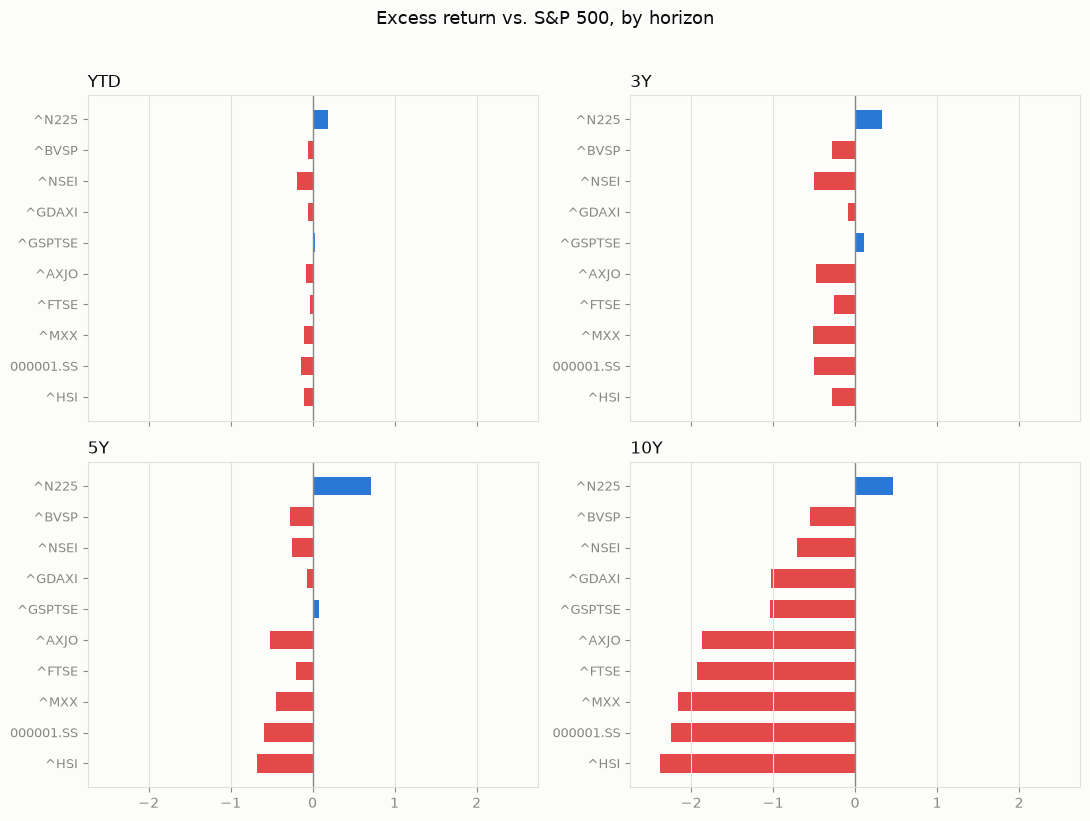

In [430]:
POSITIVE, NEGATIVE, GRID, MUTED, INK, SURFACE = "#2a78d6", "#e34948", "#e1e0d9", "#898781", "#0b0b0b", "#fcfcfb"

ticker_order = pivot_excess.sort_values("10Y").index
x_max = pivot_excess.abs().max().max() * 1.15

fig, axes = plt.subplots(2, 2, figsize=(11, 8), facecolor=SURFACE, sharex=True)
axes = axes.flatten() # [ax0, ax1, ax2, ax3]

for ax, horizon in zip(axes, horizon_order):
    ax.set_facecolor(SURFACE)
    # Select all excess values for all indexes, for a single horizon range
    values = pivot_excess.loc[ticker_order, horizon]
    colors = [POSITIVE if v >= 0 else NEGATIVE for v in values]
    ax.barh(range(len(ticker_order)), values, color=colors, height=0.6)
    ax.axvline(0, color=MUTED, linewidth=1)
    ax.set_yticks(range(len(ticker_order)))
    ax.set_yticklabels(ticker_order, color=INK, fontsize=9)
    ax.set_xlim(-x_max, x_max)
    ax.set_title(horizon, color=INK, fontsize=12, loc="left")
    ax.grid(True, axis="x", color=GRID, linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_color(GRID)
    ax.tick_params(colors=MUTED)

fig.suptitle("Excess return vs. S&P 500, by horizon", color=INK, fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

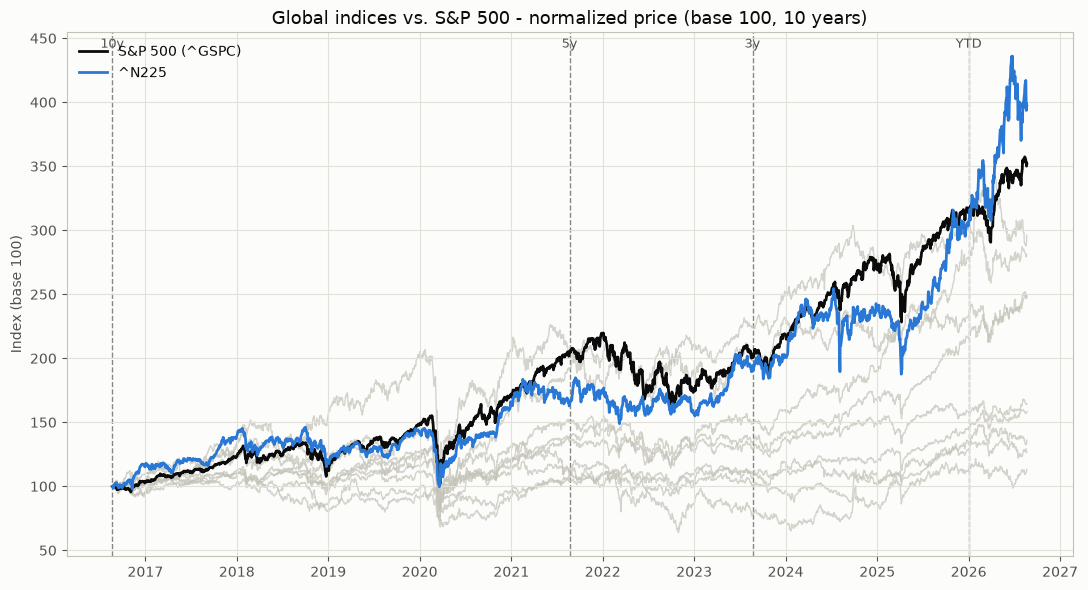

In [431]:
winners_10y = pivot_excess[pivot_excess["10Y"] > 0].index.tolist()
categorical = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
highlight_colors = {ticker: categorical[i % len(categorical)] for i, ticker in enumerate(winners_10y)}
benchmark = "^GSPC"

fig, ax = plt.subplots(figsize=(11, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for ticker in close_data.columns:
    series = close_data[ticker].dropna()
    normalized = series / series.iloc[0] * 100

    if ticker == benchmark:
        ax.plot(normalized.index, normalized.values, color=INK, linewidth=2, label="S&P 500 (^GSPC)", zorder=3)
    elif ticker in highlight_colors:
        ax.plot(normalized.index, normalized.values, color=highlight_colors[ticker], linewidth=2, label=ticker, zorder=3)
    else:
        ax.plot(normalized.index, normalized.values, color="#c3c2b7", linewidth=1, alpha=0.7, zorder=1)

y_top = ax.get_ylim()[1]
for label, ref_date in [("10y", START_DATE), ("5y", END_DATE - pd.DateOffset(years=5)),
                         ("3y", END_DATE - pd.DateOffset(years=3)), ("YTD", pd.Timestamp("2026-01-01"))]:
    ax.axvline(ref_date, color=MUTED, linestyle="--", linewidth=1, zorder=0)
    ax.text(ref_date, y_top * 0.99, label, color="#52514e", fontsize=9, ha="center", va="top")

ax.set_title("Global indices vs. S&P 500 - normalized price (base 100, 10 years)", color=INK, fontsize=13)
ax.set_ylabel("Index (base 100)", color="#52514e")
ax.tick_params(colors="#52514e")
ax.grid(True, color=GRID, linewidth=0.8)
for spine in ax.spines.values():
    spine.set_color("#c3c2b7")
ax.legend(loc="upper left", frameon=False, labelcolor=INK)

plt.tight_layout()
plt.show()

**Answer:** The trend mostly holds. The same two indexes that beat the S&P 500 YTD - Canada's S&P/TSX Composite and Japan's Nikkei 225 - also beat it over the 3-year and 5-year horizons (2 out of 10 each time). Over the 10-year horizon, though, only the Nikkei 225 stays ahead: the S&P/TSX Composite falls behind once the longer window is considered, as shown in `pivot_excess` and the charts above.

## **Question 03**

- **Problem statement: Calculate the median drawdown (in %) of significant market corrections in the S&P 500 index.**

### **Solution**

- **Download S&P 500 historical data since 1950**

In [432]:
sp500_data = yf.download(
    tickers='^GSPC',
    start='1950-01-01',
)

sp500_data.shape

[*********************100%***********************]  1 of 1 completed


(19295, 5)

In [433]:
sp500_data["Close"].head(20)

Ticker,^GSPC
Date,
1950-01-03,16.660000
1950-01-04,16.850000
1950-01-05,16.930000
1950-01-06,16.980000
1950-01-09,17.080000
1950-01-10,17.030001
1950-01-11,17.090000
1950-01-12,16.760000
1950-01-13,16.670000


- **Identify all time high closing price points**

Get all time high closing values, including each maximum value up to date:

In [434]:
sp500_data["Close"].cummax()

Ticker,^GSPC
Date,
1950-01-03,16.660000
1950-01-04,16.850000
1950-01-05,16.930000
1950-01-06,16.980000
1950-01-09,17.080000
...,...
2026-09-04,7798.990234
2026-09-08,7798.990234
2026-09-09,7798.990234


Get all time high closing values, excluding the maximum value up to date:

In [435]:
sp500_data["Close"].shift(1).cummax()

Ticker,^GSPC
Date,
1950-01-03,NaN
1950-01-04,16.660000
1950-01-05,16.850000
1950-01-06,16.930000
1950-01-09,16.980000
...,...
2026-09-04,7798.990234
2026-09-08,7798.990234
2026-09-09,7798.990234


In [436]:
ath_mask = sp500_data["Close"] > sp500_data["Close"].shift(1).cummax()

sp500_ath = sp500_data[ath_mask.squeeze()]

sp500_ath

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1950-01-04,16.850000,16.850000,16.850000,16.850000,1890000
1950-01-05,16.930000,16.930000,16.930000,16.930000,2550000
1950-01-06,16.980000,16.980000,16.980000,16.980000,2010000
1950-01-09,17.080000,17.080000,17.080000,17.080000,2520000
1950-01-11,17.090000,17.090000,17.090000,17.090000,2630000
...,...,...,...,...,...
2026-06-01,7599.959961,7617.660156,7562.609863,7582.290039,6583960000
2026-06-02,7609.779785,7620.899902,7582.990234,7595.399902,5904410000


Sanity check:

In [437]:
sp500_ath["Close"].squeeze().is_monotonic_increasing

True

In [438]:
sp500_ath["Close"].index[0]

Timestamp('1950-01-04 00:00:00')

- **Finding minimum prices between ath pairs**

In [439]:
ath_idx_dates = sp500_ath["Close"].index

len(ath_idx_dates)

1509

In [440]:
ath_idx_dates = sp500_ath["Close"].index

ath_pairs = [(ath_idx_dates[i], ath_idx_dates[i+1]) for i in range(len(ath_idx_dates) - 1)]

pair_prices = []
for date_pair in ath_pairs:
    start_ath_date = date_pair[0].strftime("%Y-%m-%d")
    next_ath_date = date_pair[1].strftime("%Y-%m-%d")

    window = sp500_data["Close"].loc[start_ath_date:next_ath_date]
    min_price = window.min().values[0]
    min_price_date = window.idxmin().iloc[0]
    duration = min_price_date - date_pair[0]

    max_price = sp500_ath["Close"].loc[start_ath_date].values[0]

    pair_prices.append({
        "start_ath_date": start_ath_date,
        "min_price_date": min_price_date,
        "duration": duration,
        "min_price": min_price,
        "max_price": max_price
    })
    

In [441]:
df_pair_prices = pd.DataFrame(pair_prices)

df_pair_prices

,start_ath_date,min_price_date,duration,min_price,max_price
0,1950-01-04,1950-01-04,0 days,16.850000,16.850000
1,1950-01-05,1950-01-05,0 days,16.930000,16.930000
2,1950-01-06,1950-01-06,0 days,16.980000,16.980000
3,1950-01-09,1950-01-10,1 days,17.030001,17.080000
4,1950-01-11,1950-01-13,2 days,16.670000,17.090000
...,...,...,...,...,...
1503,2026-05-29,2026-05-29,0 days,7580.060059,7580.060059
1504,2026-06-01,2026-06-01,0 days,7599.959961,7599.959961
1505,2026-06-02,2026-06-10,8 days,7266.990234,7609.779785
1506,2026-08-04,2026-08-06,2 days,7709.959961,7736.520020


- **Evaluating drawdown percentages**

$$
\frac{(\text{high - low})}{\text{high}} \times 100
$$

In [442]:
df_dd = df_pair_prices.copy()

df_dd["dd_%"] = (df_dd["max_price"] - df_dd["min_price"]) / df_dd["max_price"] * 100

df_dd

,start_ath_date,min_price_date,duration,min_price,max_price,dd_%
0,1950-01-04,1950-01-04,0 days,16.850000,16.850000,0.000000
1,1950-01-05,1950-01-05,0 days,16.930000,16.930000,0.000000
2,1950-01-06,1950-01-06,0 days,16.980000,16.980000,0.000000
3,1950-01-09,1950-01-10,1 days,17.030001,17.080000,0.292736
4,1950-01-11,1950-01-13,2 days,16.670000,17.090000,2.457578
...,...,...,...,...,...,...
1503,2026-05-29,2026-05-29,0 days,7580.060059,7580.060059,0.000000
1504,2026-06-01,2026-06-01,0 days,7599.959961,7599.959961,0.000000
1505,2026-06-02,2026-06-10,8 days,7266.990234,7609.779785,4.504592
1506,2026-08-04,2026-08-06,2 days,7709.959961,7736.520020,0.343308


- **Filtering for corrections with at least 5% drawdown**

In [443]:
mask_5_dd = df_dd["dd_%"] >= 5

df_corrections = df_dd[mask_5_dd]

df_corrections

,start_ath_date,min_price_date,duration,min_price,max_price,dd_%
34,1950-06-12,1950-07-17,35 days,16.680000,19.400000,14.020615
41,1950-11-24,1950-12-04,10 days,19.000000,20.320000,6.496062
61,1951-05-03,1951-06-29,57 days,20.959999,22.809999,8.110480
75,1951-10-15,1951-11-23,39 days,22.400000,23.850000,6.079668
83,1952-01-22,1952-02-20,29 days,23.090000,24.660000,6.366584
...,...,...,...,...,...,...
1407,2024-03-28,2024-04-19,22 days,4967.229980,5254.350098,5.464427
1423,2024-07-16,2024-08-05,20 days,5186.330078,5667.200195,8.485144
1445,2025-02-19,2025-04-08,48 days,4982.770020,6144.149902,18.902206
1478,2025-10-28,2025-11-20,23 days,6538.759766,6890.890137,5.110085


Visualizing the severity of each correction over time:

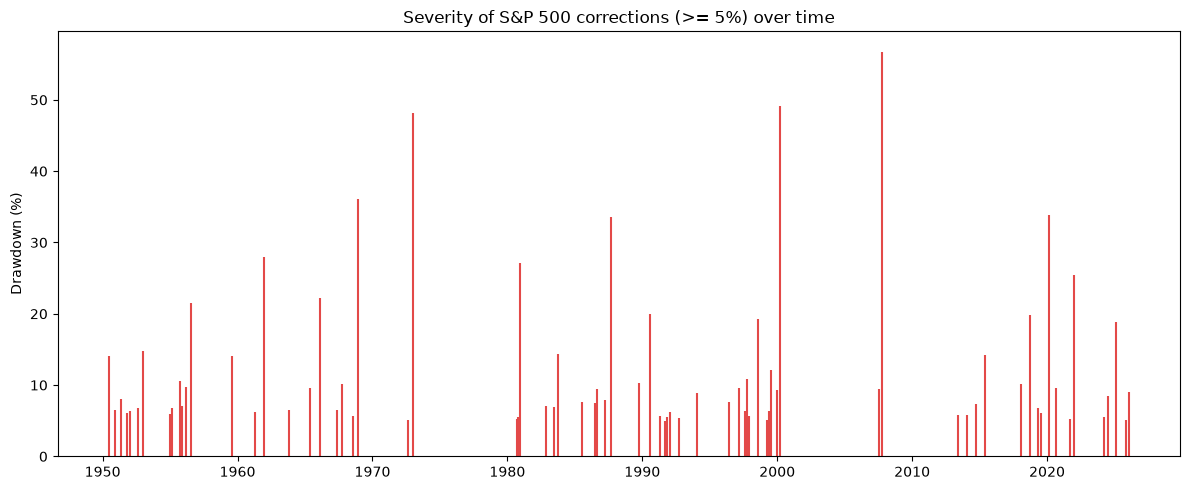

In [444]:
correction_dates = pd.to_datetime(df_corrections["start_ath_date"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.vlines(correction_dates, ymin=0, ymax=df_corrections["dd_%"], color="#e34948", linewidth=1.5)

ax.set_title("Severity of S&P 500 corrections (>= 5%) over time")
ax.set_ylabel("Drawdown (%)")
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

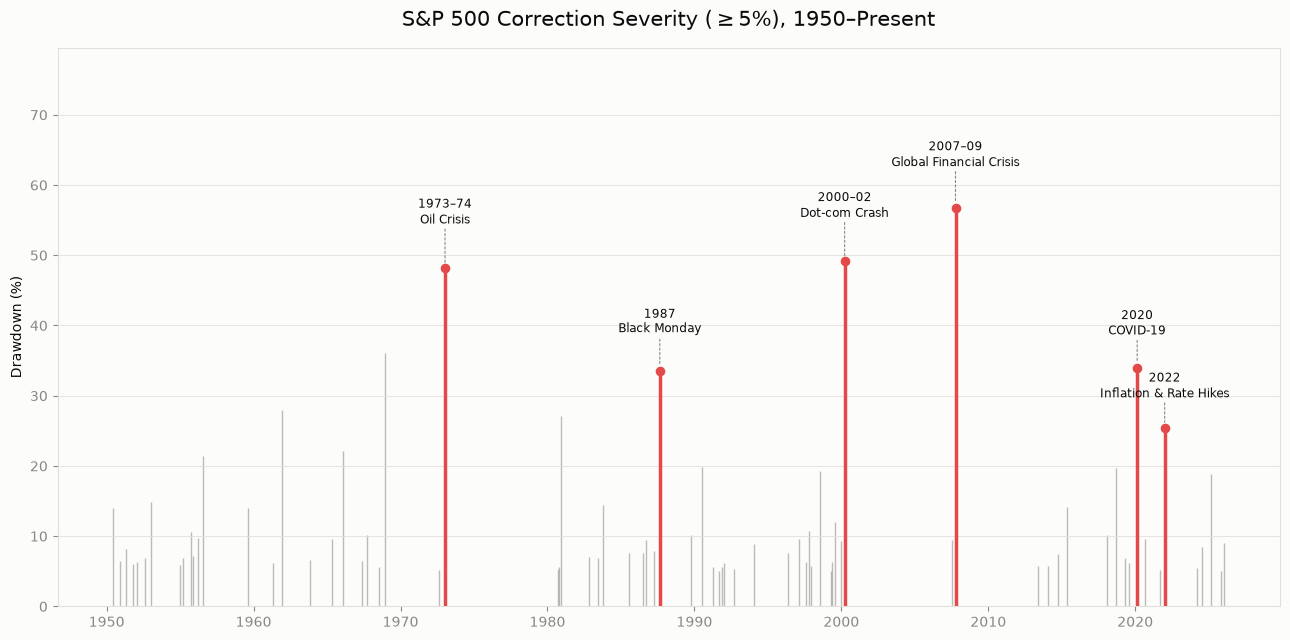

In [ ]:
crisis_events = [
    ("1973-01-11", "1973–74\nOil Crisis"),
    ("1987-08-25", "1987\nBlack Monday"),
    ("2000-03-24", "2000–02\nDot-com Crash"),
    ("2007-10-09", "2007–09\nGlobal Financial Crisis"),
    ("2020-02-19", "2020\nCOVID-19"),
    ("2022-01-03", "2022\nInflation & Rate Hikes"),
]
label_offsets = [30, 25, 30, 28, 22, 20]  # points above the bar tip; tune after a first look

INK, MUTED, GRID, SURFACE, ACCENT = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb", "#e34948"

correction_dates = pd.to_datetime(df_corrections["start_ath_date"])
crisis_dates = {d for d, _ in crisis_events}
is_crisis = df_corrections["start_ath_date"].isin(crisis_dates)

fig, ax = plt.subplots(figsize=(13, 6.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

# Background: every other correction, muted, for context
ax.vlines(
    correction_dates[~is_crisis], ymin=0, ymax=df_corrections.loc[~is_crisis, "dd_%"],
    color=MUTED, linewidth=1, alpha=0.55, zorder=1
)

# Foreground: the 6 named historical crises, highlighted
ax.vlines(
    correction_dates[is_crisis], ymin=0, ymax=df_corrections.loc[is_crisis, "dd_%"],
    color=ACCENT, linewidth=2.5, zorder=3
)
ax.scatter(
    correction_dates[is_crisis], df_corrections.loc[is_crisis, "dd_%"],
    color=ACCENT, s=35, zorder=4
)

# Staggered callout labels with thin leader lines, so close events (2020/2022) don't collide
for (date_str, label), y_offset in zip(crisis_events, label_offsets):
    row = df_corrections.loc[df_corrections["start_ath_date"] == date_str].iloc[0]
    ax.annotate(
        label,
        xy=(pd.Timestamp(date_str), row["dd_%"]), xycoords="data",
        xytext=(0, y_offset), textcoords="offset points",
        ha="center", va="bottom", fontsize=8.5, color=INK, linespacing=1.3,
        arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8, linestyle=(0, (2, 2)), shrinkA=0, shrinkB=4),
    )

ax.set_title(r"S&P 500 Correction Severity ($\geq$5%), 1950–Present", fontsize=15, color=INK, pad=16)
ax.set_ylabel("Drawdown (%)", color=INK)
ax.set_xlabel("")
ax.set_ylim(0, df_corrections["dd_%"].max() * 1.4)
ax.tick_params(colors=MUTED)
ax.grid(True, axis="y", color=GRID, linewidth=0.6, zorder=0)
for spine in ax.spines.values():
    spine.set_color(GRID)

plt.tight_layout()
plt.show()

- **Determine the 25th, 50th (median), and 75th percentiles for correction durations and drawdowns**

In [446]:
duration_percentiles = df_corrections["duration"].dt.days.quantile([0.25, 0.5, 0.75])
dd_percentiles = df_corrections["dd_%"].quantile([0.25, 0.5, 0.75])

display(duration_percentiles)
display(dd_percentiles)

0.25    22.00
0.50    40.50
0.75    86.25
Name: duration, dtype: float64

0.25     6.234677
0.50     7.986358
0.75    14.019826
Name: dd_%, dtype: float64

Sanity check - comparing the largest corrections found against the assignment's reference list of top 10 largest corrections:

In [447]:
df_dd.sort_values(by="dd_%", ascending=False).head(10)

,start_ath_date,min_price_date,duration,min_price,max_price,dd_%
1039,2007-10-09,2009-03-09,517 days,676.530029,1565.150024,56.775388
1030,2000-03-24,2002-10-09,929 days,776.760010,1527.459961,49.146948
527,1973-01-11,1974-10-03,630 days,62.279999,120.239998,48.203593
492,1968-11-29,1970-05-26,543 days,69.290001,108.370003,36.061641
1294,2020-02-19,2020-03-23,33 days,2237.399902,3386.149902,33.924960
703,1987-08-25,1987-12-04,101 days,223.919998,336.769989,33.509515
326,1961-12-12,1962-06-26,196 days,52.320000,72.639999,27.973568
551,1980-11-28,1982-08-12,622 days,102.419998,140.520004,27.113582
1385,2022-01-03,2022-10-12,282 days,3577.030029,4796.560059,25.425097
445,1966-02-09,1966-10-07,240 days,73.199997,94.059998,22.177335


> **Answer:** The median drawdown of significant (≥5%) S&P 500 corrections since 1950 is approximately **8.0%** (25th percentile ≈ 6.2%, 75th percentile ≈ 14.0%). The median correction takes about **40 days** to go from peak to trough (25th percentile ≈ 22 days, 75th percentile ≈ 86 days). Sorting the results by drawdown severity reproduces the same top 10 corrections listed in the assignment's reference table - dates and durations match exactly, and drawdown percentages now land within a few hundredths of a percentage point of the cited values (e.g., 56.78% vs. the reference 56.8% for 2007-2009), confirming the corrected calculation.

## **Question 04**

- **Problem statement: Calculate the median 2-day percentage change in stock prices following positive earnings surprise days.**

- **Additional Problem statement: Is there a correlation between the magnitude of the earnings surprise and the stock price reaction? Does the market react differently to earnings surprises during bull vs. bear markets?**

### **Solution**

- **Download earning and historical data**

In [448]:
amzn_ticker = 'AMZN'
ticker_obj = yf.Ticker(amzn_ticker)
df_amzn_earn = ticker_obj.get_earnings_dates()

df_amzn_earn.head()

,EPS Estimate,Reported EPS,Surprise(%)
Earnings Date,,,
2026-10-29 16:00:00-04:00,1.95,NaN,NaN
2026-07-30 16:00:00-04:00,1.83,5.75,215.02
2026-04-29 16:00:00-04:00,1.64,2.78,69.02
2026-02-05 16:00:00-05:00,1.95,1.95,0.22
2025-10-30 16:00:00-04:00,1.56,1.95,25.20


In [449]:
df_amzn_hist = yf.download(
    tickers=amzn_ticker,
    period="max"
)

df_amzn_hist.head() 

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
1997-05-15,0.097917,0.125000,0.096354,0.121875,1443120000
1997-05-16,0.086458,0.098958,0.085417,0.098438,294000000
1997-05-19,0.085417,0.088542,0.081250,0.088021,122136000
1997-05-20,0.081771,0.087500,0.081771,0.086458,109344000
1997-05-21,0.071354,0.082292,0.068750,0.081771,377064000


- **Evaluate 2-day percentage returns**

To evaluate the percentual 2-day return, we must consider three consecutive trading days:

$$
R_{2d} = \frac{\text{close price}_{day 3}}{\text{close price}_{day 1}} - 1.
$$

In [450]:
df_amzn_hist["Close"].isna().sum()

Ticker
AMZN    0
dtype: int64

In [451]:
df_amzn_hist["r2d"] = df_amzn_hist["Close"].shift(-1) / df_amzn_hist["Close"].shift(1) - 1

df_amzn_hist[["Close", "r2d"]].head()

Price,Close,r2d
Ticker,AMZN,
Date,,
1997-05-15,0.097917,NaN
1997-05-16,0.086458,-0.127659
1997-05-19,0.085417,-0.054211
1997-05-20,0.081771,-0.164639
1997-05-21,0.071354,-0.146494


- **Merging R2D with earnings dates**

In [452]:
r2d_series = df_amzn_hist["r2d"].squeeze()

r2d_series.loc["2026-07-30"]

np.float64(0.19823513737353848)

In [453]:
r2d_series = df_amzn_hist["r2d"].squeeze()

df_amzn_earn["earnings_date"] = df_amzn_earn.index.tz_localize(None).normalize()
df_amzn_earn["r2d"] = df_amzn_earn["earnings_date"].map(r2d_series)

df_amzn_earn = df_amzn_earn.reset_index(drop=True)

df_amzn_earn

,EPS Estimate,Reported EPS,Surprise(%),earnings_date,r2d
0,1.95,NaN,NaN,2026-10-29,NaN
1,1.83,5.75,215.02,2026-07-30,0.198235
2,1.64,2.78,69.02,2026-04-29,0.020639
3,1.95,1.95,0.22,2026-02-05,-0.097300
4,1.56,1.95,25.20,2025-10-30,0.060443
5,1.32,1.68,27.19,2025-07-31,-0.067075
6,1.36,1.59,16.77,2025-05-01,0.030149
7,1.48,1.86,25.29,2025-02-06,-0.029724
8,1.14,1.43,25.22,2024-10-31,0.026981
9,1.02,1.26,23.76,2024-08-01,-0.102043


- **Filtering positive earnings surprises and calculating the median 2-day return**

In [454]:
df_amzn_earn_valid = df_amzn_earn.dropna(subset=["Surprise(%)", "r2d"])

positive_surprises = df_amzn_earn_valid[df_amzn_earn_valid["Surprise(%)"] > 0]

quantiles_r2d_positive = positive_surprises["r2d"].quantile([0.25, 0.50, 0.75])
quantiles_r2d_positive

0.25   -0.046797
0.50    0.003528
0.75    0.048070
Name: r2d, dtype: float64

> **Answer:** The median 2-day return following positive earnings surprises is approximately **+0.35%**.

- **Correlation**

In [455]:
correlation = df_amzn_earn_valid["r2d"].corr(df_amzn_earn_valid["Surprise(%)"])
correlation

np.float64(0.21906338566924655)

- **Additional: Is there a correlation between the magnitude of the earnings surprise and the stock price reaction? Does the market react differently to earnings surprises during bull vs. bear markets?**

O dia presente é classificado como bull se o fechamento do pregão anterior estiver acima da média dos últimos 200 fechamentos, incluindo o próprio pregão anterior.

In [456]:
import numpy as np

df_sp500 = yf.download(
    "^GSPC",
    start="2019-01-01",  # Inclusive
    period=None,
    end="2026-07-31", # Exclusive
    multi_level_index=False
)

df_sp500["sma_200"] = df_sp500["Close"].rolling(200).mean()

df_sp500["market_regime"] = np.where(
    df_sp500["Close"].shift(1) > df_sp500["sma_200"].shift(1),
    "bull",
    "bear"
)

[*********************100%***********************]  1 of 1 completed


In [457]:
df_amzn_earn_valid["market_regime"] = (
    df_amzn_earn_valid["earnings_date"].map(df_sp500["market_regime"])
)

df_amzn_earn_valid

,EPS Estimate,Reported EPS,Surprise(%),earnings_date,r2d,market_regime
1,1.83,5.75,215.02,2026-07-30,0.198235,bull
2,1.64,2.78,69.02,2026-04-29,0.020639,bull
3,1.95,1.95,0.22,2026-02-05,-0.097300,bull
4,1.56,1.95,25.20,2025-10-30,0.060443,bull
5,1.32,1.68,27.19,2025-07-31,-0.067075,bull
6,1.36,1.59,16.77,2025-05-01,0.030149,bear
7,1.48,1.86,25.29,2025-02-06,-0.029724,bull
8,1.14,1.43,25.22,2024-10-31,0.026981,bull
9,1.02,1.26,23.76,2024-08-01,-0.102043,bull
10,0.83,0.98,17.67,2024-04-30,-0.010831,bull


In [458]:
positive_surprises = df_amzn_earn_valid[df_amzn_earn_valid["Surprise(%)"] > 0]

positive_surprises.groupby("market_regime")["r2d"].agg(
    count="count",
    median="median",
    mean="mean"
)

,count,median,mean
market_regime,,,
bear,3,0.030149,-0.007818
bull,17,0.002579,0.006833


In [459]:
correlations = {
    regime: group["Surprise(%)"].corr(group["r2d"])
    for regime, group in df_amzn_earn_valid.groupby("market_regime")
}

correlations

{'bear': np.float64(-0.21930572626982894),
 'bull': np.float64(0.35145482071247774)}

In [460]:
df_amzn_earn_valid

,EPS Estimate,Reported EPS,Surprise(%),earnings_date,r2d,market_regime
1,1.83,5.75,215.02,2026-07-30,0.198235,bull
2,1.64,2.78,69.02,2026-04-29,0.020639,bull
3,1.95,1.95,0.22,2026-02-05,-0.097300,bull
4,1.56,1.95,25.20,2025-10-30,0.060443,bull
5,1.32,1.68,27.19,2025-07-31,-0.067075,bull
6,1.36,1.59,16.77,2025-05-01,0.030149,bear
7,1.48,1.86,25.29,2025-02-06,-0.029724,bull
8,1.14,1.43,25.22,2024-10-31,0.026981,bull
9,1.02,1.26,23.76,2024-08-01,-0.102043,bull
10,0.83,0.98,17.67,2024-04-30,-0.010831,bull


> **Answer:** The overall Pearson correlation between the earnings surprise percentage and AMZN's 2-day return was approximately 0.22, indicating a weak positive association. Therefore, larger earnings surprises were associated with slightly higher short-term returns in this sample, but the relationship was not strong enough to suggest a consistent market response.

> For the bull-versus-bear comparison, the market regime was defined using the S&P 500. An earnings date was classified as bull when the previous trading day's S&P 500 closing level was above its 200-day moving average, and as bear otherwise. This definition used only information available before the earnings announcement.

>Among positive earnings surprises, the median 2-day AMZN return was 3.01% during bear regimes and 0.26% during bull regimes. However, the bear result was based on only three observations. Moreover, its mean return was −0.78%, compared with +0.68% during bull regimes, because one −10.6% return strongly affected the bear-market average.

>The correlations also differed by regime: −0.22 during bear periods and +0.35 during bull periods. Nevertheless, the bear correlation was based on only five observations, compared with nineteen in the bull group. Consequently, these differences should be treated as descriptive and exploratory. The available sample does not provide sufficient evidence to conclude that AMZN reacts systematically differently to earnings surprises during bull and bear markets.

Visualizing the earnings-surprise reaction, tying together the correlation and the bull/bear regime split:

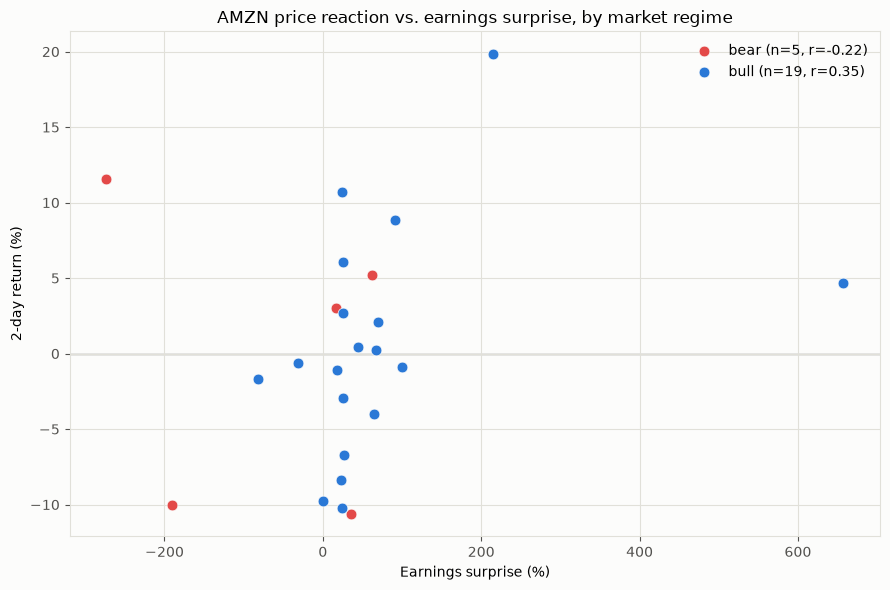

In [461]:
fig, ax = plt.subplots(figsize=(9, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

regime_colors = {"bull": "#2a78d6", "bear": "#e34948"}

for regime, group in df_amzn_earn_valid.groupby("market_regime"):
    ax.scatter(
        group["Surprise(%)"], group["r2d"] * 100,
        color=regime_colors[regime],
        label=f"{regime} (n={len(group)}, r={correlations[regime]:.2f})",
        s=60, edgecolor="#fcfcfb", linewidth=0.5, zorder=3
    )

ax.axhline(0, color="#898781", linewidth=1, zorder=1)
ax.set_xlabel("Earnings surprise (%)")
ax.set_ylabel("2-day return (%)")
ax.set_title("AMZN price reaction vs. earnings surprise, by market regime")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
for spine in ax.spines.values():
    spine.set_color("#e1e0d9")
ax.tick_params(colors="#52514e")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

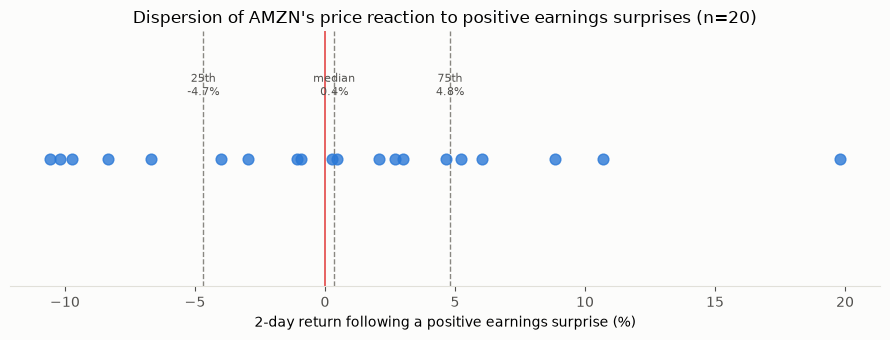

In [462]:
fig, ax = plt.subplots(figsize=(9, 3.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

y_vals = positive_surprises["r2d"] * 100
ax.scatter(y_vals, [0] * len(y_vals), color="#2a78d6", s=60, alpha=0.8, zorder=3)

quantile_labels = ["25th", "median", "75th"]
for q, label in zip(quantiles_r2d_positive, quantile_labels):
    ax.axvline(q * 100, color="#898781", linestyle="--", linewidth=1, zorder=1)
    ax.text(q * 100, 0.15, f"{label}\n{q*100:.1f}%", ha="center", fontsize=8, color="#52514e")

ax.axvline(0, color="#e34948", linewidth=1.2, zorder=2)
ax.set_yticks([])
ax.set_xlabel("2-day return following a positive earnings surprise (%)")
ax.set_title("Dispersion of AMZN's price reaction to positive earnings surprises (n=20)")
for spine in ["top", "left", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#e1e0d9")
ax.tick_params(colors="#52514e")
ax.set_ylim(-0.3, 0.3)

plt.tight_layout()
plt.show()

## **Question 5 - Capstone Project Idea**

**Answer:**

I want to investigate market regimes in cryptoassets and develop a modeling framework to estimate the **direction** and **risk** of future Bitcoin and Ethereum returns. Solana may later be incorporated to evaluate whether the identified patterns generalize to another major cryptoasset.

The initial project scope is defined as follows:

- **Direction:** the model will estimate whether the cumulative return over the selected horizon will be positive or negative, together with probabilities such as $P(\text{up})$ and $P(\text{down})$. After probability calibration, this prediction may be converted into a buy, sell, or hold signal according to predefined probability and risk thresholds.

- **Risk:** metrics that capture future asset volatility and potential losses, such as realized volatility and drawdown.

- **Prediction Horizon:** the period between the current observation and the future outcome. I plan to begin with a 7-day horizon and later expand the analysis to 30 days.


The project will begin with a historical dataset containing daily OHLCV data, as shown in this module.
Yahoo Finance will be used as the initial source. Later, I will evaluate the inclusion of more crypto-specific data from CoinGecko and Binance, as well as economic and financial variables from FRED, such as interest rates, Treasury yields, inflation indicators, and traditional-market volatility.

Market-regime identification will constitute the unsupervised part of the project. A market regime is a recurring market state characterized by a particular combination of conditions, such as trend, volatility, liquidity, and market stress.

At each date (t), the observed market conditions will be represented by a stochastic feature vector:

$$
\mathbf{x}_t = \left(x_{1,t};x_{2,t},\ldots;x_{p,t}\right).
$$

Each component of $\mathbf{x}_t$ will correspond to a relevant market indicator. As these indicators change over time, the sequence of vectors will trace a temporal trajectory through the market-feature space. Each row in the observed dataset can therefore be understood as one realization of the stochastic vector $\mathbf{x}_t$.

The regime-identification pipeline will include:

- **Feature construction:** historical price, return, volatility, volume, and external information will be transformed into indicators that compose the market-state vector $\mathbf{x}_t$ at each date.

- **Standardization:** variables measured on different scales will be transformed so that they can be meaningfully compared.

- **PCA:** Principal Component Analysis will produce a lower-dimensional representation of the market-feature space by summarizing its main sources of variation. It will also support visualization and help identify the combinations of indicators that distinguish different market conditions.

- **KMeans:** the reduced observations will be grouped into clusters of similar market conditions. Each observation will then be assigned to a discrete market regime $Z_t$.

After identifying the regimes, I plan to use a Markov chain to investigate their temporal dynamics. The Markov model will be applied to the sequence of discrete regimes $Z_t$, rather than directly to the original feature vectors. A Markov transition probability represents the probability of moving from the current regime $(i)$ to another regime $(j)$:

$$
P(Z_{t+1}=j \mid Z_t=i)
$$

The transition matrix will therefore describe:

- the persistence probability of each regime;
- the probability of changing from one regime to another;
- the most likely regime following the current state;
- which transitions are commonly associated with subsequent periods of greater volatility or negative returns.

The complete unsupervised sequence can be summarized as:

$$
\mathbf{x}_t
\xrightarrow{\text{PCA}}
\text{reduced market representation}
\xrightarrow{\text{KMeans}}
Z_t
\xrightarrow{\text{Markov chain}}
P(Z_{t+1}\mid Z_t)
$$

The supervised models will use the processed market indicators, the current regime $Z_t$, and potentially its transition probabilities as inputs. They will produce the directional probabilities and risk estimates defined above, allowing me to investigate whether information about the current regime and its expected evolution improves predictive performance.

The Markov chain will not be used to predict asset prices directly. Its purpose will be to model the persistence and evolution of the identified regimes. The current regime, its persistence probability, and its transition probabilities may then provide contextual information for the supervised models.

All stages will be evaluated chronologically. Training data will always precede validation and test data, and standardization, PCA, KMeans, Markov transition probabilities, and supervised models will be fitted without access to future observations. This procedure will prevent data leakage and provide a more realistic evaluation of predictive performance.

As a later extension, I plan to develop an LLM/RAG assistant that explains the predicted direction, associated probabilities, risk estimates, and identified market regime. It may also retrieve historically similar periods to contextualize the current analysis. Finally, these outputs could support a Telegram notification system reporting relevant regime changes, transition probabilities, directional signals, and risk alerts. The project will be developed incrementally, with each course module contributing a new component to the final pipeline.

## **Question 06 - Investigate new metrics**

To complement the daily OHLCV data, I explored additional metrics that may be useful for the proposed capstone project.

Bitcoin and Ethereum were selected as the initial assets, and the following metrics were investigated:

- retrospective returns over 1, 7, and 30 days;
- 30-day rolling volatility;
- 30-day rolling drawdown;
- 30-day volume z-score;

### **Yahoo Finance data**

The analysis starts in 2018 so that both assets are evaluated over the same period.

In [463]:
btc_data = yf.Ticker("BTC-USD").history(
    start="2018-01-01",
    auto_adjust=True,
    actions=False
)

eth_data = yf.Ticker("ETH-USD").history(
    start="2018-01-01",
    auto_adjust=True,
    actions=False
)

display(btc_data.head(), eth_data.head())

,Open,High,Low,Close,Volume
Date,,,,,
2018-01-01 00:00:00+00:00,14112.200195,14112.200195,13154.700195,13657.200195,10291200000
2018-01-02 00:00:00+00:00,13625.000000,15444.599609,13163.599609,14982.099609,16846600192
2018-01-03 00:00:00+00:00,14978.200195,15572.799805,14844.500000,15201.000000,16871900160
2018-01-04 00:00:00+00:00,15270.700195,15739.700195,14522.200195,15599.200195,21783199744
2018-01-05 00:00:00+00:00,15477.200195,17705.199219,15202.799805,17429.500000,23840899072


,Open,High,Low,Close,Volume
Date,,,,,
2018-01-01 00:00:00+00:00,755.757019,782.530029,742.004028,772.640991,2595760128
2018-01-02 00:00:00+00:00,772.346008,914.830017,772.346008,884.443970,5783349760
2018-01-03 00:00:00+00:00,886.000000,974.471008,868.450989,962.719971,5093159936
2018-01-04 00:00:00+00:00,961.713013,1045.079956,946.085999,980.921997,6502859776
2018-01-05 00:00:00+00:00,975.750000,1075.390015,956.325012,997.719971,6683149824


### **Metric definitions**

#### **Retrospective returns**

The retrospective return measures the percentage price variation over a previous period.

For a retrospective horizon of $h$ days, it is calculated as:

$$
R_{t,h} = \frac{P_t}{P_{t-h}} - 1
$$

where $P_t$ is the closing price on the current date and $P_{t-h}$ is the closing price observed $h$ days earlier.

Returns over 1, 7, and 30 days provide information about short- and medium-term price direction. These variables may help characterize momentum and distinguish different market conditions.

#### **Volatility**

Medida da dispersão dos retornos percentuais diários em uma janela móvel de 30 dias. Para cada data analisada, o desvio-padrão é calculado usando os 30 retornos diários disponíveis até aquela data.

$$
\sigma_{t,30}
=
\operatorname{std}
\left(
R_{t-29,1},\ldots,R_{t,1}
\right)
$$

Higher values indicate that recent daily returns are more dispersed and, consequently, that the asset is experiencing greater price instability. This metric may help identify high- and low-volatility market regimes.

#### **Rolling drawdown**

The 30-day rolling drawdown measures how far the current closing price is below the highest closing price observed within the 30-day window ending on the current date.

$$
DD_{t,30}
=
\frac{P_t}{\max(P_{t-29},\ldots,P_t)}-1
$$

A value of zero indicates that the current price is at the highest level of its 30-day window. Negative values indicate a decline relative to that recent maximum.

This metric represents recent market stress and the magnitude of losses relative to a local price peak.

#### **Volume z-score**

The 30-day volume z-score measures how far the current daily trading volume is from its 30-day rolling average, expressed in units of standard deviation.

$$
Z^{volume}_{t,30}
=
\frac{V_t-\overline{V}_{t,30}}
{s_{V,t,30}}
$$

Positive values indicate above-average trading activity, while negative values indicate below-average activity. Unusually high trading volume may be associated with significant price movements or changes in market conditions.



### **Feature construction**

The following function receives an OHLCV DataFrame and adds the metrics derived from historical price and volume data.

All rolling metrics use only observations available up to each date. Therefore, no future observations are used during feature construction.

In [464]:
def add_market_metrics(data: pd.DataFrame) -> pd.DataFrame:
    result = data.copy()

    # Retrospective returns
    result["return_1d"] = result["Close"].pct_change(periods=1)
    result["return_7d"] = result["Close"].pct_change(periods=7)
    result["return_30d"] = result["Close"].pct_change(periods=30)

    # 30-day rolling volatility of daily returns
    result["volatility_30d"] = (
        result["return_1d"]
        .rolling(window=30)
        .std()
    )

    # Drawdown relative to the highest close in the last 30 days
    rolling_max_30d = (
        result["Close"]
        .rolling(window=30)
        .max()
    )

    result["drawdown_30d"] = (
        result["Close"] / rolling_max_30d - 1
    )

    # 30-day volume z-score
    volume_mean_30d = (
        result["Volume"]
        .rolling(window=30)
        .mean()
    )

    volume_std_30d = (
        result["Volume"]
        .rolling(window=30)
        .std()
    )

    result["volume_zscore_30d"] = (
        (result["Volume"] - volume_mean_30d)
        / volume_std_30d
    )

    return result

The function is applied separately to Bitcoin and Ethereum because each asset has its own historical price, return, and volume distributions.

In [465]:
btc_metrics = add_market_metrics(btc_data)
eth_metrics = add_market_metrics(eth_data)

metric_columns = [
    "Close",
    "Volume",
    "return_1d",
    "return_7d",
    "return_30d",
    "volatility_30d",
    "drawdown_30d",
    "volume_zscore_30d"
]

btc_metrics[metric_columns].tail()

,Close,Volume,return_1d,return_7d,return_30d,volatility_30d,drawdown_30d,volume_zscore_30d
Date,,,,,,,,
2026-09-09 00:00:00+00:00,78259.523438,29192409298,-0.002283,0.012407,0.224516,0.025040,-0.037064,-0.102449
2026-09-10 00:00:00+00:00,76568.125000,30120111719,-0.021613,-0.057875,0.204813,0.025485,-0.057875,-0.061024
2026-09-11 00:00:00+00:00,77173.796875,37410998193,0.007910,-0.031356,0.217206,0.025431,-0.050423,0.405775
2026-09-12 00:00:00+00:00,77270.468750,12664765797,0.001253,-0.031988,0.218735,0.025420,-0.049233,-1.257083
2026-09-13 00:00:00+00:00,77338.976562,13392167936,0.000887,-0.037474,0.228079,0.025317,-0.048390,-1.174400


In [466]:
eth_metrics[metric_columns].tail()

,Close,Volume,return_1d,return_7d,return_30d,volatility_30d,drawdown_30d,volume_zscore_30d
Date,,,,,,,,
2026-09-09 00:00:00+00:00,2466.913818,14955608804,-0.007255,0.031534,0.318304,0.038735,-0.019230,0.092209
2026-09-10 00:00:00+00:00,2437.098633,16781828594,-0.012086,-0.028278,0.295383,0.038936,-0.031083,0.295030
2026-09-11 00:00:00+00:00,2514.733887,27812010346,0.031856,0.023882,0.338953,0.039089,-0.000218,1.605282
2026-09-12 00:00:00+00:00,2525.944580,8012825772,0.004458,0.018224,0.340741,0.039081,0.000000,-0.925647
2026-09-13 00:00:00+00:00,2507.760010,8960338944,-0.007199,-0.002700,0.333454,0.039153,-0.007199,-0.831352


The initial missing values are expected. Retrospective and rolling metrics require a minimum number of previous observations before they can be calculated.

For example, the 30-day volatility requires 30 valid daily returns.

### **Volatility visualization**

The 30-day rolling volatility can be visualized to identify periods in which daily returns became more dispersed.

Because Bitcoin and Ethereum volatility is expressed using the same unit, both series can be compared in the same plot. The values are multiplied by 100 only for presentation as percentages.

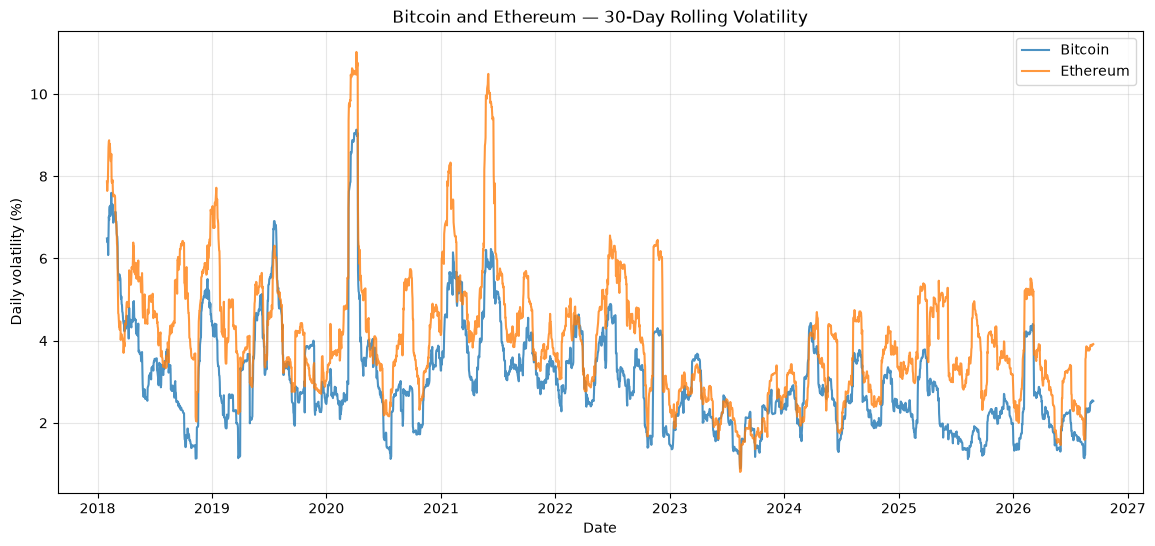

In [467]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    btc_metrics.index,
    btc_metrics["volatility_30d"] * 100,
    label="Bitcoin",
    alpha=0.8
)

ax.plot(
    eth_metrics.index,
    eth_metrics["volatility_30d"] * 100,
    label="Ethereum",
    alpha=0.8
)

ax.set_title("Bitcoin and Ethereum — 30-Day Rolling Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Daily volatility (%)")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

### **Initial conclusions**

The selected metrics describe complementary dimensions of the cryptoasset market:

- retrospective returns describe recent price direction;
- rolling volatility represents the dispersion of recent returns;
- rolling drawdown measures losses relative to a recent maximum;
- the volume z-score identifies unusually high or low trading activity;

Together, these metrics provide an initial representation of trend, risk, market stress, and trading activity. They may later compose the market-state vector used for regime identification and supervised prediction.